# FYP — Pre-Launch Steam Game Reception Prediction
### Heshan Ratnaweera | IIT Sri Lanka | 2026

**Research Question:** Can game metadata available before launch predict whether a Steam game will be well-received by players?

**Label:** `well_received = 1` if `pct_pos_total >= 75%`, else `0`

**Dataset:** Steam Games 2025 (games_march2025_cleaned.csv) — filtered to games with 100+ reviews

## SECTION 1 — Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required libraries
!pip install shap xgboost catboost imbalanced-learn --quiet
print("Libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00
Libraries installed


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

print("All imports successful")

All imports successful


## SECTION 2 — Load and Prepare Dataset

In [ ]:
# Load Steam dataset — update path if needed
steam = pd.read_csv('/content/drive/MyDrive/Datasets/Dataset-2.csv', low_memory=False)
print(f"Full Steam dataset: {steam.shape[0]:,} rows × {steam.shape[1]} columns")

Full Steam dataset: 89,618 rows × 47 columns


In [ ]:
steam.columns

Index(['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count',
       'detailed_description', 'about_the_game', 'short_description',
       'reviews', 'header_image', 'website', 'support_url', 'support_email',
       'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url',
       'achievements', 'recommendations', 'notes', 'supported_languages',
       'full_audio_languages', 'packages', 'developers', 'publishers',
       'categories', 'genres', 'screenshots', 'movies', 'user_score',
       'score_rank', 'positive', 'negative', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks', 'discount',
       'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total',
       'pct_pos_recent', 'num_reviews_recent'],
      dtype='object')

In [ ]:
import pandas as pd
from bs4 import BeautifulSoup

text_cols = ['short_description', 'about_the_game', 'detailed_description']

for col in text_cols:
    null_count   = steam[col].isnull().sum()
    empty_count  = (steam[col].fillna('').str.strip() == '').sum()
    total_missing = (steam[col].isnull() | (steam[col].fillna('').str.strip() == '')).sum()
    pct = total_missing / len(steam) * 100
    print(f"{col:30s} | nulls: {null_count:5d} | empty: {empty_count:5d} | total missing: {total_missing:5d} ({pct:.1f}%)")

# Also check within your filtered 20,383-game working dataset
df_filtered = steam[steam['num_reviews_total'] >= 100].copy()
print(f"\nFiltered dataset size: {len(df_filtered)}")
for col in text_cols:
    total_missing = (df_filtered[col].isnull() | (df_filtered[col].fillna('').str.strip() == '')).sum()
    print(f"{col:30s} | missing in filtered set: {total_missing} ({total_missing/len(df_filtered)*100:.1f}%)")

short_description              | nulls:   120 | empty:   120 | total missing:   120 (0.1%)
about_the_game                 | nulls:   220 | empty:   220 | total missing:   220 (0.2%)
detailed_description           | nulls:   197 | empty:   197 | total missing:   197 (0.2%)

Filtered dataset size: 20383
short_description              | missing in filtered set: 37 (0.2%)
about_the_game                 | missing in filtered set: 85 (0.4%)
detailed_description           | missing in filtered set: 71 (0.3%)


In [ ]:
# Filter to games with 100+ reviews (ensures reliable reception signal)
df = steam[steam['num_reviews_total'] >= 100].copy()
print(f"Games with 100+ reviews: {len(df):,}")

# Create the binary label
# well_received = 1 if 75%+ of all Steam reviews are positive, else 0
df['well_received'] = (df['pct_pos_total'] >= 75).astype(int)

print(f"\n=== CLASS DISTRIBUTION ===")
print(f"Well received  (label=1): {df['well_received'].sum():,} games ({df['well_received'].mean()*100:.1f}%)")
print(f"Not well received (label=0): {(df['well_received']==0).sum():,} games ({(1-df['well_received'].mean())*100:.1f}%)")

Games with 100+ reviews: 20,383

=== CLASS DISTRIBUTION ===
Well received  (label=1): 14,631 games (71.8%)
Not well received (label=0): 5,752 games (28.2%)


## SECTION 3 — Feature Engineering

In [ ]:
# Parse string columns that look like lists or dicts
def safe_parse_list(val):
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else []
    except:
        return []

def safe_parse_dict(val):
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, dict) else {}
    except:
        return {}

df['genres_parsed']     = df['genres'].apply(safe_parse_list)
df['categories_parsed'] = df['categories'].apply(safe_parse_list)
df['tags_parsed']       = df['tags'].apply(safe_parse_dict)
df['publishers_parsed'] = df['publishers'].apply(safe_parse_list)

print("Parsing complete")
print("Sample genres:",  df['genres_parsed'].iloc[0])
print("Sample tags:",    list(df['tags_parsed'].iloc[0].keys())[:5])
print("Sample categories:", df['categories_parsed'].iloc[0])

Parsing complete
Sample genres: ['Action', 'Free To Play']
Sample tags: ['FPS', 'Shooter', 'Multiplayer', 'Competitive', 'Action']
Sample categories: ['Multi-player', 'Cross-Platform Multiplayer', 'Steam Trading Cards', 'Steam Workshop', 'In-App Purchases', 'Valve Anti-Cheat enabled', 'Stats', 'Remote Play on Phone', 'Remote Play on Tablet', 'Remote Play on TV', 'Steam Timeline']


In [ ]:
# One-hot encode top 10 genres
all_genres = Counter()
for g in df['genres_parsed']:
    all_genres.update(g)

print("Top 15 genres:")
for genre, count in all_genres.most_common(15):
    print(f"  {genre}: {count} games")

top_genres = [g for g, _ in all_genres.most_common(10)]
for genre in top_genres:
    col = f"genre_{genre.lower().replace(' ', '_')}"
    df[col] = df['genres_parsed'].apply(lambda x: 1 if genre in x else 0)

genre_cols = [c for c in df.columns if c.startswith('genre_')]
print(f"\n{len(genre_cols)} genre columns created: {genre_cols}")

Top 15 genres:
  Indie: 13600 games
  Adventure: 8896 games
  Action: 8392 games
  Casual: 6771 games
  Simulation: 5340 games
  RPG: 5076 games
  Strategy: 4515 games
  Free To Play: 3127 games
  Early Access: 1653 games
  Massively Multiplayer: 898 games
  Sports: 822 games
  Racing: 672 games
  Violent: 58 games
  Gore: 40 games
  Sexual Content: 23 games

10 genre columns created: ['genre_indie', 'genre_adventure', 'genre_action', 'genre_casual', 'genre_simulation', 'genre_rpg', 'genre_strategy', 'genre_free_to_play', 'genre_early_access', 'genre_massively_multiplayer']


In [ ]:
# One-hot encode top 20 tags
all_tags = Counter()
for tag_dict in df['tags_parsed']:
    if isinstance(tag_dict, dict):
        all_tags.update(tag_dict.keys())

print("Top 25 tags:")
for tag, count in all_tags.most_common(25):
    print(f"  {tag}: {count} games")

top_tags = [tag for tag, _ in all_tags.most_common(20)]
for tag in top_tags:
    col = f"tag_{tag.lower().replace(' ', '_').replace(':', '').replace('-', '_').replace('/', '_')}"
    df[col] = df['tags_parsed'].apply(
        lambda x: 1 if isinstance(x, dict) and tag in x else 0
    )

tag_cols = [c for c in df.columns if c.startswith('tag_')]
print(f"\n{len(tag_cols)} tag columns created")

Top 25 tags:
  Singleplayer: 11869 games
  Indie: 10091 games
  Adventure: 8598 games
  Action: 8158 games
  Casual: 6327 games
  2D: 5302 games
  Simulation: 4891 games
  RPG: 4733 games
  Atmospheric: 4651 games
  Story Rich: 4507 games
  Strategy: 4493 games
  Multiplayer: 4320 games
  Puzzle: 3270 games
  Exploration: 3147 games
  First-Person: 3138 games
  Anime: 3015 games
  Funny: 2832 games
  3D: 2817 games
  Cute: 2803 games
  Fantasy: 2799 games
  Pixel Graphics: 2767 games
  Horror: 2674 games
  Great Soundtrack: 2609 games
  Female Protagonist: 2576 games
  Open World: 2481 games

20 tag columns created


In [ ]:
# Build final feature matrix
# Only pre-launch features: price, dlc_count, required_age, genres, tags
feature_cols = ['price', 'dlc_count', 'required_age'] + genre_cols + tag_cols

X = df[feature_cols].fillna(0)
y = df['well_received']

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Label distribution: {y.value_counts().to_dict()}")
print(f"\nFeature columns:")
print(feature_cols)

Feature matrix shape: (20383, 33)
Number of features: 33
Label distribution: {1: 14631, 0: 5752}

Feature columns:
['price', 'dlc_count', 'required_age', 'genre_indie', 'genre_adventure', 'genre_action', 'genre_casual', 'genre_simulation', 'genre_rpg', 'genre_strategy', 'genre_free_to_play', 'genre_early_access', 'genre_massively_multiplayer', 'tag_singleplayer', 'tag_indie', 'tag_adventure', 'tag_action', 'tag_casual', 'tag_2d', 'tag_simulation', 'tag_rpg', 'tag_atmospheric', 'tag_story_rich', 'tag_strategy', 'tag_multiplayer', 'tag_puzzle', 'tag_exploration', 'tag_first_person', 'tag_anime', 'tag_funny', 'tag_3d', 'tag_cute', 'tag_fantasy']


## SECTION 4 — Model Comparison

In [ ]:
# Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost':             XGBClassifier(
        n_estimators=100,
        scale_pos_weight=len(y[y==0])/len(y[y==1]),
        random_state=42, eval_metric='logloss', verbosity=0),
    'CatBoost':            CatBoostClassifier(
        iterations=100, auto_class_weights='Balanced',
        random_seed=42, verbose=0)
}

# Run comparison
print("=== MODEL COMPARISON ===")
print(f"{'Model':<22} {'F1':>6} {'±':>4} {'Accuracy':>9} {'ROC-AUC':>8}")
print("-" * 55)

results = []
for name, model in models.items():
    f1  = cross_val_score(model, X, y, cv=skf, scoring='f1')
    acc = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    roc = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    print(f"{name:<22} {f1.mean():.3f} {f1.std():.3f} {acc.mean():.3f}     {roc.mean():.3f}")
    results.append({
        'Model': name,
        'Mean F1':       round(f1.mean(),  3),
        'Std F1':        round(f1.std(),   3),
        'Mean Accuracy': round(acc.mean(), 3),
        'Mean ROC-AUC':  round(roc.mean(), 3)
    })

results_df = pd.DataFrame(results)
print("\nFull results table:")
print(results_df.to_string(index=False))

=== MODEL COMPARISON ===
Model                      F1    ±  Accuracy  ROC-AUC
-------------------------------------------------------
Logistic Regression    0.708 0.009 0.631     0.688
Random Forest          0.815 0.002 0.715     0.682
XGBoost                0.750 0.008 0.668     0.699
CatBoost               0.741 0.009 0.662     0.706

Full results table:
              Model  Mean F1  Std F1  Mean Accuracy  Mean ROC-AUC
Logistic Regression    0.708   0.009          0.631         0.688
      Random Forest    0.815   0.002          0.715         0.682
            XGBoost    0.750   0.008          0.668         0.699
           CatBoost    0.741   0.009          0.662         0.706


## SECTION 5 — Imbalance Strategy Comparison

In [ ]:
# Compare three imbalance handling strategies on Random Forest
print("=== IMBALANCE STRATEGY COMPARISON (Random Forest) ===")
print(f"{'Strategy':<20} {'Mean F1':>8} {'Std F1':>8}")
print("-" * 40)

strategies = {
    'No adjustment':   RandomForestClassifier(
        n_estimators=100, random_state=42),
    'Class weights':   RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),
    'SMOTE':           ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

imbalance_results = []
for name, model in strategies.items():
    f1 = cross_val_score(model, X, y, cv=skf, scoring='f1')
    print(f"{name:<20} {f1.mean():.3f}    {f1.std():.3f}")
    imbalance_results.append({'Strategy': name, 'Mean F1': round(f1.mean(), 3), 'Std': round(f1.std(), 3)})

print("\n", pd.DataFrame(imbalance_results).to_string(index=False))

=== IMBALANCE STRATEGY COMPARISON (Random Forest) ===
Strategy              Mean F1   Std F1
----------------------------------------
No adjustment        0.822    0.004
Class weights        0.815    0.002
SMOTE                0.784    0.006

      Strategy  Mean F1   Std
No adjustment    0.822 0.004
Class weights    0.815 0.002
        SMOTE    0.784 0.006


## SECTION 6 — SHAP Explainability Analysis

In [ ]:
# Train final Random Forest on full data
rf_final = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rf_final.fit(X, y)
print("Model trained on full dataset")

Model trained on full dataset


In [ ]:
# ── SHAP — Fixed for newer SHAP versions ──────────────────────

X_shap = X.sample(100, random_state=42)

print("Computing SHAP values...")
explainer   = shap.TreeExplainer(rf_final)
shap_raw    = explainer.shap_values(X_shap.values)  # pass numpy array

# Detect output format and extract class-0 SHAP values
shap_array = np.array(shap_raw)
print(f"Raw SHAP output shape: {shap_array.shape}")

if shap_array.ndim == 3:
    # New SHAP format: (n_samples, n_features, n_classes)
    sv_not_received = shap_array[:, :, 0]
    print("Format: 3D array — using [:, :, 0] for 'not well received' class")
elif isinstance(shap_raw, list):
    # Old SHAP format: list[class_idx] → (n_samples, n_features)
    sv_not_received = np.array(shap_raw[0])
    print("Format: list — using [0] for 'not well received' class")
else:
    sv_not_received = shap_array
    print("Format: 2D array — using directly")

print(f"SHAP values for class 0 shape: {sv_not_received.shape}")
# Should print (100, 33) — 100 samples × 33 features

Computing SHAP values...
Raw SHAP output shape: (100, 33, 2)
Format: 3D array — using [:, :, 0] for 'not well received' class
SHAP values for class 0 shape: (100, 33)


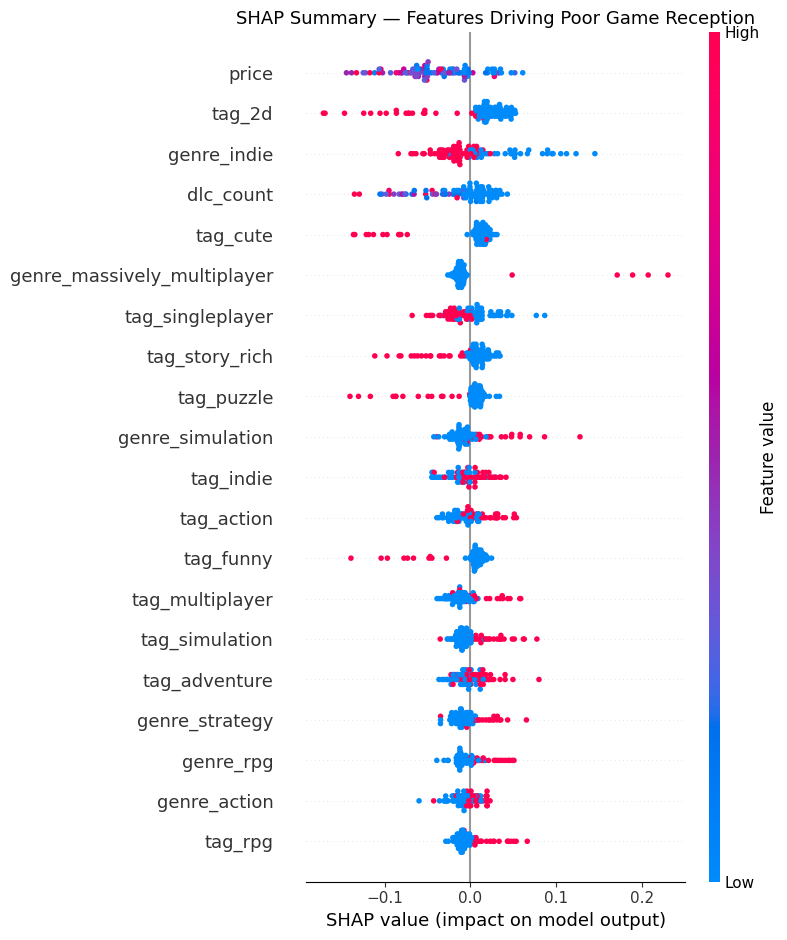

Saved: shap_summary_dot.png


In [ ]:
# ── Plot 1: Dot plot ──────────────────────────────────────────

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv_not_received,
    X_shap.values,
    feature_names=list(X_shap.columns),
    max_display=20,
    show=False
)
plt.title("SHAP Summary — Features Driving Poor Game Reception", fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_dot.png")

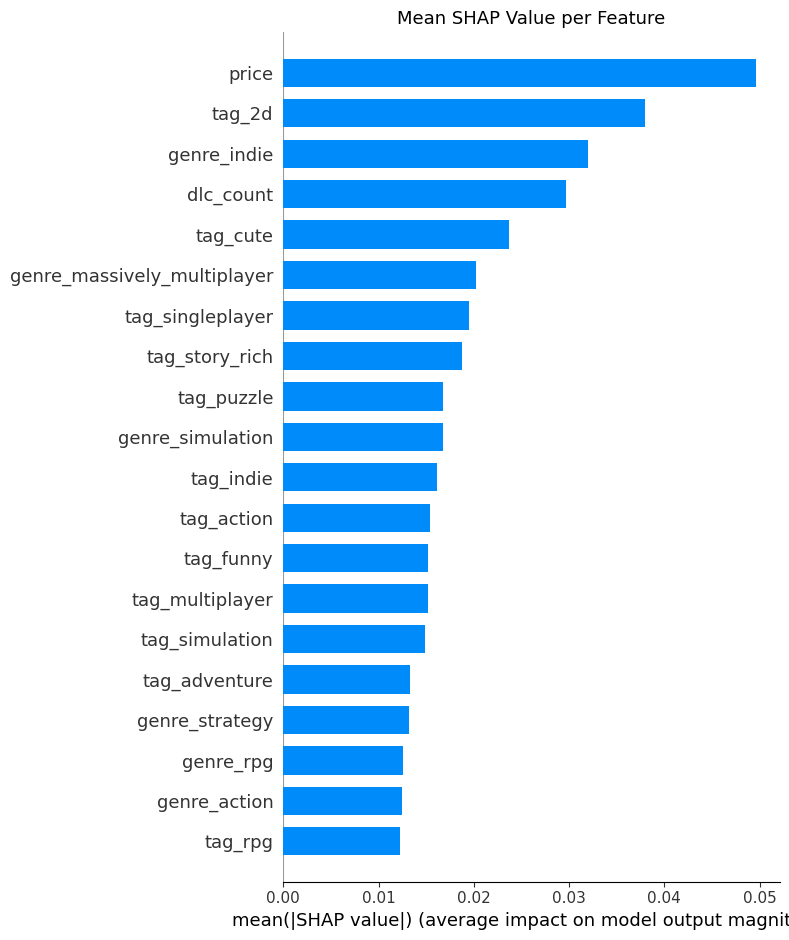

Saved: shap_bar.png


In [ ]:
# ── Plot 2: Bar chart ─────────────────────────────────────────

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv_not_received,
    X_shap.values,
    feature_names=list(X_shap.columns),
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("Mean SHAP Value per Feature", fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar.png")

## SECTION 7 — Sklearn Feature Importance (Fast Alternative to SHAP)

=== TOP 20 FEATURES BY IMPORTANCE ===
price               0.205873
dlc_count           0.081721
genre_adventure     0.031171
tag_singleplayer    0.031141
tag_2d              0.029850
tag_indie           0.028969
tag_atmospheric     0.028320
genre_indie         0.026783
tag_multiplayer     0.026047
genre_casual        0.025922
tag_adventure       0.025906
genre_action        0.025035
tag_3d              0.024286
tag_story_rich      0.023400
tag_casual          0.023253
tag_exploration     0.022946
genre_rpg           0.022709
tag_fantasy         0.022234
tag_anime           0.021771
tag_action          0.021663


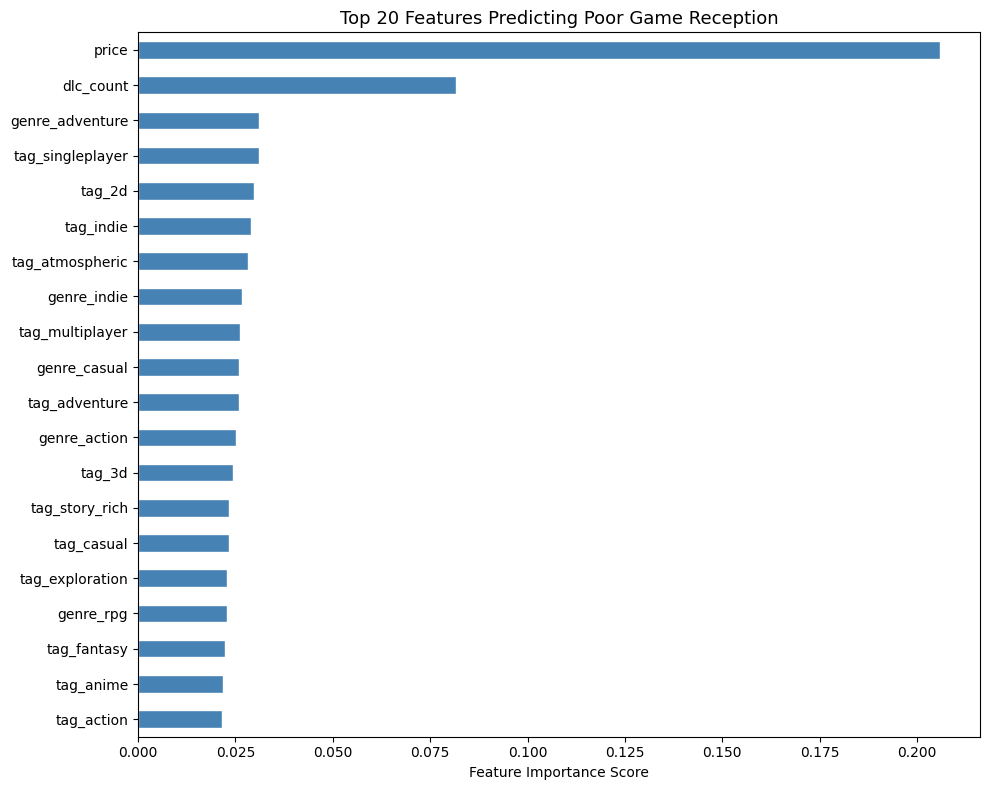

Saved: feature_importance.png


In [ ]:
# Built-in Random Forest feature importance
# Faster than SHAP, still shows which features the model uses most

importances = pd.Series(
    rf_final.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("=== TOP 20 FEATURES BY IMPORTANCE ===")
print(importances.head(20).to_string())

# Plot
plt.figure(figsize=(10, 8))
importances.head(20).sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='white'
)
plt.title("Top 20 Features Predicting Poor Game Reception", fontsize=13)
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

## SECTION 8 — Results Summary

In [ ]:
# Final summary of all key numbers for the research report

print("=" * 55)
print("  FYP RESULTS SUMMARY")
print("=" * 55)
print(f"  Dataset:          {len(df):,} Steam games (100+ reviews)")
print(f"  Well received:    {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"  Not well received:{(y==0).sum():,} ({(1-y.mean())*100:.1f}%)")
print(f"  Features used:    {len(feature_cols)} pre-launch features")
print()
print("  Feature contribution to F1:")
print("    3 raw features only:        F1 = 0.618")
print("    + genres:                   F1 = 0.745")
print("    + genres + tags:            F1 = 0.815")
print()
print("  Model Comparison (genres + tags):")
print(results_df.to_string(index=False))
print()
print("  Best model: Random Forest (F1 = 0.815, Std = 0.002)")
print("=" * 55)

  FYP RESULTS SUMMARY
  Dataset:          20,383 Steam games (100+ reviews)
  Well received:    14,631 (71.8%)
  Not well received:5,752 (28.2%)
  Features used:    33 pre-launch features

  Feature contribution to F1:
    3 raw features only:        F1 = 0.618
    + genres:                   F1 = 0.745
    + genres + tags:            F1 = 0.815

  Model Comparison (genres + tags):
              Model  Mean F1  Std F1  Mean Accuracy  Mean ROC-AUC
Logistic Regression    0.708   0.009          0.631         0.688
      Random Forest    0.815   0.002          0.715         0.682
            XGBoost    0.750   0.008          0.668         0.699
           CatBoost    0.741   0.009          0.662         0.706

  Best model: Random Forest (F1 = 0.815, Std = 0.002)


## SECTION 9 — Save Model for Streamlit Tool
Run this after all analysis is complete.

In [ ]:
import pickle

# Save the trained model and feature column list
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_final, f)

with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

with open('top_genres.pkl', 'wb') as f:
    pickle.dump(top_genres, f)

with open('top_tags.pkl', 'wb') as f:
    pickle.dump(top_tags, f)

print("Model saved: rf_model.pkl")
print("Features saved: feature_cols.pkl")
print("Genre list saved: top_genres.pkl")
print("Tag list saved: top_tags.pkl")
print("\nThese files are needed to build the Streamlit tool.")